In [7]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

In [8]:
from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import pathlib
FIGDIR = pathlib.Path("figs_tesis"); FIGDIR.mkdir(exist_ok=True)

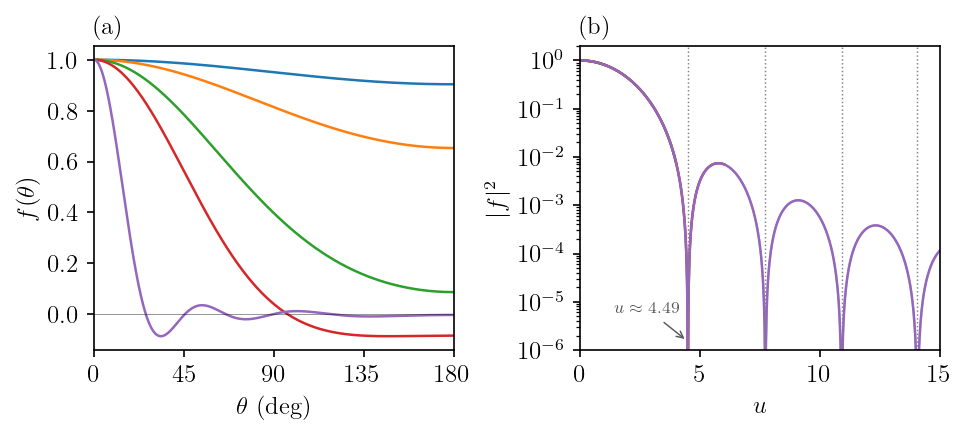

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Sphere form factor:  f(u) = 3/u^3 (sin u - u cos u) ----
def form_factor(u):
    u = np.asarray(u, dtype=float)
    out = np.empty_like(u)
    small = np.abs(u) < 1e-6
    out[small]  = 1.0 - u[small]**2 / 10.0            # Taylor -> f(0) = 1
    us = u[~small]
    out[~small] = 3.0/us**3 * (np.sin(us) - us*np.cos(us))
    return out

apply(width_frac=1.0)

alphas = [0.5, 1, 2, 3, 10]
theta  = np.linspace(0, np.pi, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44*TEXTWIDTH_IN))

# (a) f(theta) vs theta
for a in alphas:
    u = 2*a*np.sin(theta/2)
    ax1.plot(np.degrees(theta), form_factor(u), label=fr"$\alpha={a}$")
ax1.axhline(0, color="k", lw=0.5, alpha=0.4)
ax1.set_xlabel(r"$\theta$ (deg)")
ax1.set_ylabel(r"$f(\theta)$")
ax1.set_xlim(0, 180)
ax1.set_xticks([0, 45, 90, 135, 180])
# ax1.legend(title=r"size param.", fontsize=8, title_fontsize=8)
ax1.set_title(r"(a)", loc="left")

# (b) |f|^2 vs u (log): universal collapse + zeros / side lobes
u_ref = np.linspace(1e-3, 15, 3000)
ax2.plot(u_ref, form_factor(u_ref)**2, color="0.75", lw=1.0, zorder=0,
         label=r"universal $|f(u)|^2$")
for a in alphas:
    u = 2*a*np.sin(theta/2)
    ax2.plot(u, form_factor(u)**2, label=fr"$\alpha={a}$")
zeros = [4.493, 7.725, 10.904, 14.066]            # roots of tan u = u
for z in zeros:
    ax2.axvline(z, color="gray", ls=":", lw=0.7)
ax2.annotate(r"$u\approx4.49$", xy=(4.493, 1.5e-6), xytext=(1.4, 6e-6),
             fontsize=8, color="0.35",
             arrowprops=dict(arrowstyle="->", color="0.35", lw=0.7))
ax2.set_yscale("log")
ax2.set_ylim(1e-6, 2)
ax2.set_xlim(0, 15)
ax2.set_xlabel(r"$u$")
ax2.set_ylabel(r"$|f|^2$")
# ax2.legend(fontsize=8, loc="upper right")
ax2.set_title(r"(b)", loc="left")

fig.savefig(FIGDIR / "sphere_form_factor.pdf")

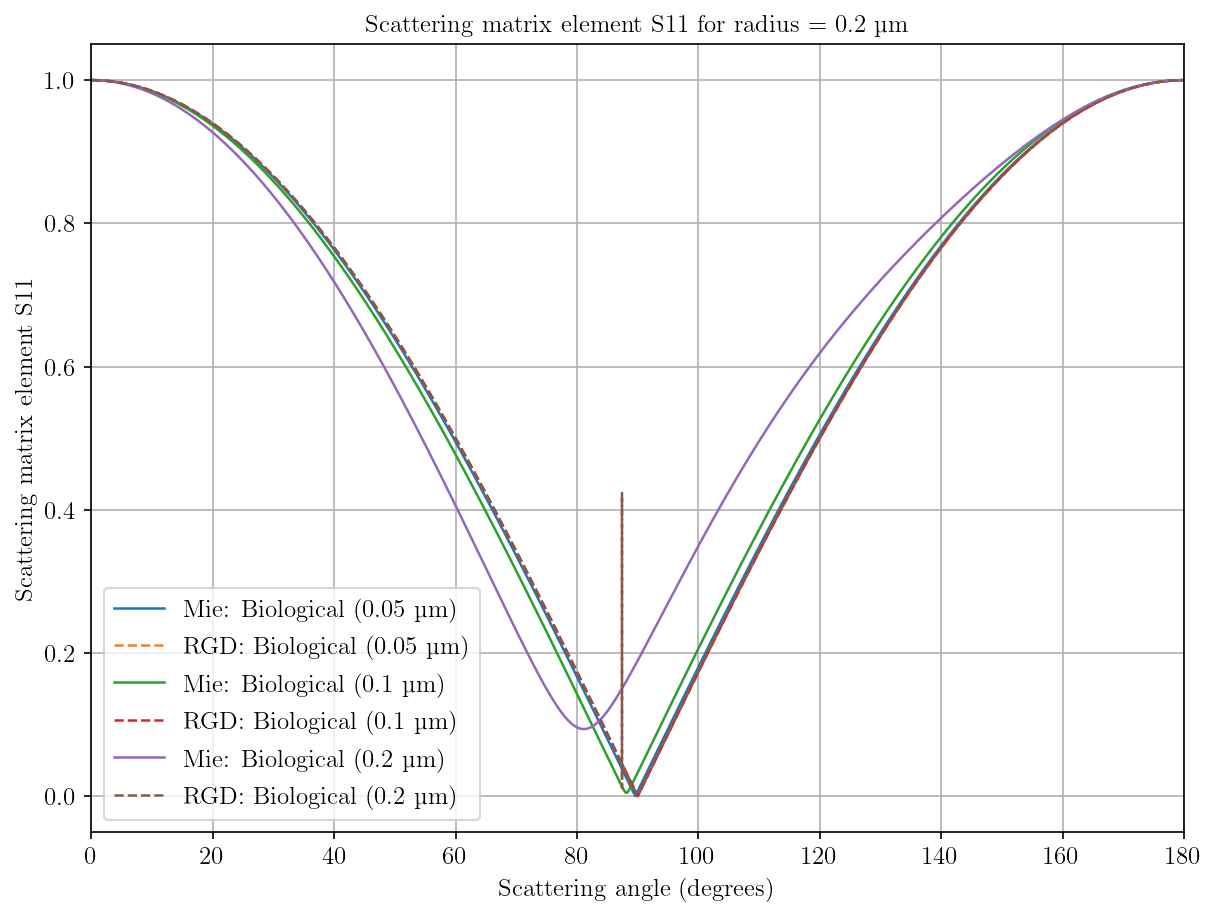

In [10]:
from utils.styles import apply
import numpy as np

from luminis_mc import (
    RGDMedium, MieMedium, RayleighDebyeEMCPhaseFunction, MiePhaseFunction
)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

save_path = "/Users/niaggar/Documents/Thesis/Results"


# Things to study:
#   - Particle size vs Size parameter
#   - Particle size vs Anisotropy factor
#   - Particle size vs Mean free path
#   - Volume fraction vs Mean free path
#   - Volume fraction vs Max scattering angle for CBS
#   - Particle size vs Max scattering angle for CBS

# Units are micrometers (µm)

# RGD have two conditions for validity:
#   1. |m-1| << 1
#   2. size parameter * |m-1| << 1


n_medium = 1.33
wavelength = 0.514
k_medium = 2 * np.pi * n_medium / wavelength

# Silica particles
n_particle_silica = 1.46
r_min_silica = 0.030
r_max_silica = 0.500

# Biological particles
n_particle_bio = 1.38
r_min_bio = 0.050
r_max_bio = 0.500

# Polystyrene particles
n_particle_poly = 1.59
r_min_poly = 0.020
r_max_poly = 0.500


volume_fraction_sweep = np.linspace(0.01, 0.2, 5)

# Phase function parameters
phasef_theta_min = 0.0
phasef_theta_max = np.pi
phasef_ndiv = 100_000

# Simulation parameters
n_photons = 50_000_000

# Phase function parameters
phasef_theta_min = 0.0
phasef_theta_max = np.pi
phasef_ndiv = 500_000



def plot_phase_function(radius, n_particle, label):
    phase_mie = MiePhaseFunction(wavelength, radius, n_particle, n_medium, phasef_ndiv, phasef_theta_min, phasef_theta_max)
    phase = RayleighDebyeEMCPhaseFunction(wavelength, radius, n_particle, n_medium, phasef_ndiv, phasef_theta_min, phasef_theta_max)

    x_axis = np.linspace(0, 180, phasef_ndiv)
    y_axis_mie = [phase_mie.rho_phase_function(theta) for theta in np.radians(x_axis)]
    y_axis_rgd = [phase.rho_phase_function(theta) for theta in np.radians(x_axis)]

    plt.plot(x_axis, y_axis_mie, label=f"Mie: {label}")
    plt.plot(x_axis, y_axis_rgd, label=f"RGD: {label}", linestyle="dashed")
    plt.xlabel("Scattering angle (degrees)")
    plt.ylabel("Phase function")
    plt.title(f"Phase function for radius = {radius} µm")


def plot_scattering_matrix(radius, n_particle, label):
    phase_mie = MiePhaseFunction(wavelength, radius, n_particle, n_medium, phasef_ndiv, phasef_theta_min, phasef_theta_max)
    phase = RayleighDebyeEMCPhaseFunction(wavelength, radius, n_particle, n_medium, phasef_ndiv, phasef_theta_min, phasef_theta_max)

    medium_mie = MieMedium(phase_mie, radius, n_particle, n_medium, wavelength)
    medium = RGDMedium(phase, radius, n_particle, n_medium, wavelength)

    x_axis = np.linspace(0, 180, phasef_ndiv)
    matrix_mie = [medium_mie.scattering_matrix(theta, 0) for theta in np.radians(x_axis)]
    matrix_rgd = [medium.scattering_matrix(theta, 0) for theta in np.radians(x_axis)]

    s2_mie = np.array([s.get(0,0) for s in matrix_mie])
    s1_mie = np.array([s.get(1,1) for s in matrix_mie])

    s2_rgd = np.array([s.get(0,0) for s in matrix_rgd])
    s1_rgd = np.array([s.get(1,1) for s in matrix_rgd])

    ratio_mie = np.abs(s2_mie) / np.abs(s1_mie)
    ratio_rgd = np.abs(s2_rgd) / np.abs(s1_rgd)

    plt.plot(x_axis, ratio_mie, label=f"Mie: {label}")
    plt.plot(x_axis, ratio_rgd, label=f"RGD: {label}", linestyle="dashed")
    plt.xlabel("Scattering angle (degrees)")
    plt.ylabel("Scattering matrix element S11")
    plt.title(f"Scattering matrix element S11 for radius = {radius} µm")

    # Use log scale for y-axis
    # plt.yscale("log")



# # Plot phase functions for different particle sizes
# plt.figure(figsize=(8, 6))
# plot_phase_function(0.05, 1.01, "Biological (0.05 µm)")
# plot_phase_function(0.1, 1.01, "Biological (0.1 µm)")
# plot_phase_function(0.2, 1.01, "Biological (0.2 µm)")
# plt.legend()
# plt.xlim(0, 180)
# plt.grid()
# plt.tight_layout()


apply()
plt.figure(figsize=(8, 6))
plot_scattering_matrix(0.05, 1.01, "Biological (0.05 µm)")
plot_scattering_matrix(0.1, 1.01, " Biological (0.1 µm)")
plot_scattering_matrix(0.2, 1.01, "Biological (0.2 µm)")
plt.legend()
plt.xlim(0, 180)
plt.grid()
plt.show()

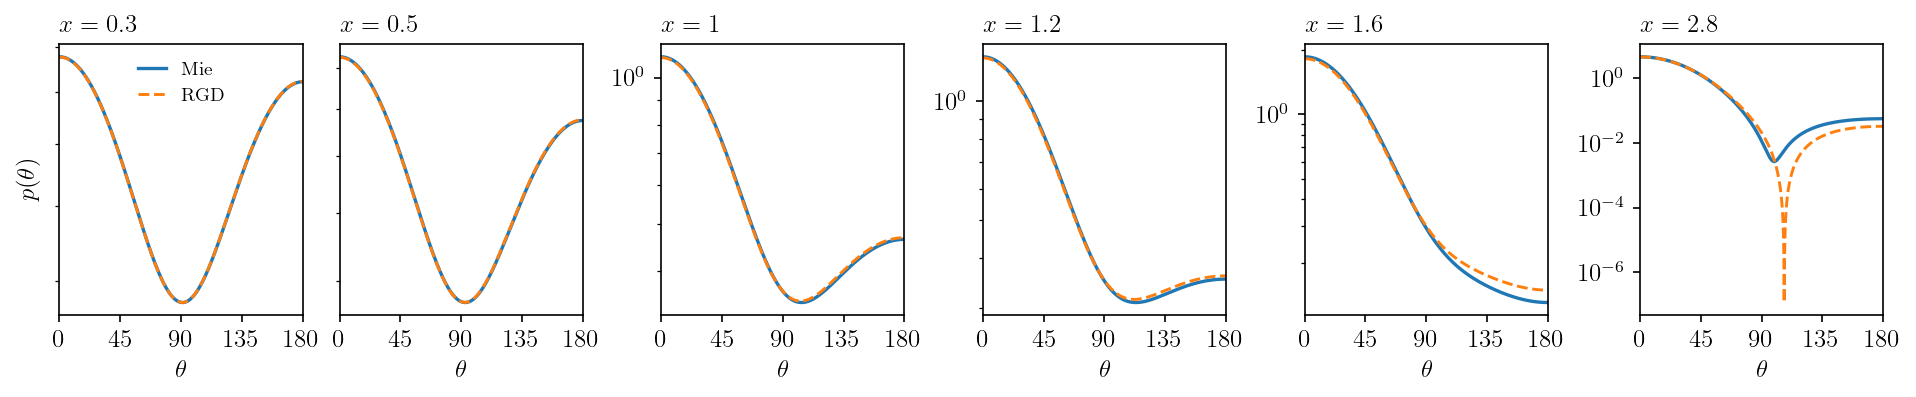

In [11]:
from utils.styles import apply
import numpy as np
import matplotlib.pyplot as plt

from luminis_mc import MiePhaseFunction, RayleighDebyeEMCPhaseFunction

# --- medium / material ---
n_medium   = 1.33
wavelength = 0.514
k_medium   = 2 * np.pi * n_medium / wavelength     # µm^-1

m = 1.10                       # relative index, |m-1| << 1
n_particle = m * n_medium      # -> 1.463

# --- size parameters to compare (alpha = k_medium * radius) ---
alphas = [0.3, 0.5, 1, 1.2, 1.6, 2.8]

# --- angular grid + phase-function resolution ---
theta_deg = np.linspace(0, 180, 1000)
theta_rad = np.radians(theta_deg)

phasef_ndiv = 500_000
phasef_theta_min = 0.0
phasef_theta_max = np.pi

apply(width_frac=1.0)
fig, axes = plt.subplots(1, len(alphas), figsize=(2*TEXTWIDTH_IN, 0.40*TEXTWIDTH_IN), sharex=True)

for ax, alpha in zip(axes, alphas):
    radius = alpha / k_medium

    mie = MiePhaseFunction(wavelength, radius, n_particle, n_medium,
                           phasef_ndiv, phasef_theta_min, phasef_theta_max)
    rgd = RayleighDebyeEMCPhaseFunction(wavelength, radius, n_particle, n_medium,
                                        phasef_ndiv, phasef_theta_min, phasef_theta_max)

    p_mie = np.array([mie.rho_phase_function(t) for t in theta_rad])
    p_rgd = np.array([rgd.rho_phase_function(t) for t in theta_rad])

    ax.semilogy(theta_deg, p_mie, lw=1.6, label="Mie")
    ax.semilogy(theta_deg, p_rgd, lw=1.4, ls="--", label="RGD")

    ax.set_title(fr"$x={alpha}$", loc="left")
    ax.set_xlabel(r"$\theta$")
    ax.set_xlim(0, 180)
    ax.set_xticks([0, 45, 90, 135, 180])
    ax.grid(False)
    ax.yaxis.set_minor_formatter(plt.NullFormatter())

axes[0].set_ylabel(r"$p(\theta)$")
axes[0].legend(frameon=False, handlelength=1.5, fontsize=9)

fig.savefig(FIGDIR / "mie_vs_rgd_phase.pdf")

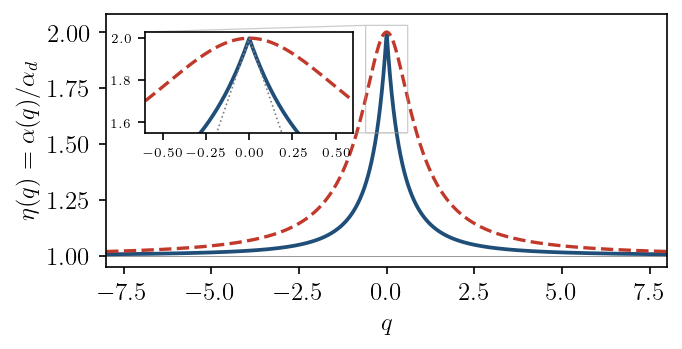

In [12]:
from utils.styles import apply
import numpy as np
import matplotlib.pyplot as plt

# --- AWM enhancement, reduced transverse momentum q = q_perp l* = k l* theta ---
z0_over_l = 2.0/3.0
b = 2.0*z0_over_l                       # = 4/3

def F(Q):
    """Interference kernel; F(0) = 1 + 2 z0/l* = 7/3."""
    Q = np.asarray(Q, dtype=float)
    Qs = np.where(Q < 1e-9, 1.0, Q)     # avoid /0
    val = 1.0/(1.0 + Q)**2 * (1.0 + (1.0 - np.exp(-b*Qs))/Qs)
    return np.where(Q < 1e-9, 1.0 + b, val)

def eta(q, qa=0.0):
    """Albedo enhancement eta(q) = alpha(q)/alpha_d.
    Absorption enters BOTH terms: the background is the interference kernel at qa,
    so eta(0) = 2 for any qa (reciprocity), only the cusp gets rounded."""
    return 1.0 + F(np.sqrt(q**2 + qa**2)) / F(qa)

qa = 0.6                                # absorption strength q_a = kappa_a l*
q  = np.linspace(-8, 8, 4000)

apply(width_frac=0.7)
fig, ax = plt.subplots(figsize=(0.7*TEXTWIDTH_IN, 0.35*TEXTWIDTH_IN))

ax.plot(q, eta(q, 0.0), lw=1.8, color="#1f4e79", label="pure diffusion")
ax.plot(q, eta(q, qa),  lw=1.6, color="#c0392b", ls="--",
        label=fr"with absorption ($q_a={qa}$)")
ax.axhline(1.0, color="k", lw=0.5, alpha=0.4)
ax.set_xlabel(r"$q$")
ax.set_ylabel(r"$\eta(q) = \alpha(q)/\alpha_d$")
ax.set_xlim(-8, 8)
ax.set_ylim(0.95, 2.08)
# ax.legend(fontsize=8, loc="upper right", framealpha=0.9)

# --- inset: triangular cusp vs rounded (parabolic) max near q = 0 ---
axin = ax.inset_axes([0.07, 0.53, 0.37, 0.40])
qin = np.linspace(-0.6, 0.6, 2000)
axin.plot(qin, eta(qin, 0.0), lw=1.8, color="#1f4e79")
axin.plot(qin, eta(qin, qa),  lw=1.6, color="#c0392b", ls="--")
axin.plot(qin, 2 - 2.381*np.abs(qin), lw=0.8, color="0.5", ls=":")  # cusp asymptote
axin.set_xlim(-0.6, 0.6)
axin.set_ylim(1.55, 2.03)
axin.tick_params(labelsize=6)
ax.indicate_inset_zoom(axin, edgecolor="0.6", lw=0.6)

fig.savefig(FIGDIR / "cbs_awm_lineshape.pdf")